# **Cleaning final_merged_cleaned.csv with Pre-Processing & Feature Engineering**

**Import packages and data**

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [4]:
df=pd.read_csv("final_merged_cleaned.csv")
df.head()

,patientunitstayid,gender,age,ethnicity,admissionheight,admissionweight,unittype,bmi,dialysis,wbc,...,sbp_min,dbp_min,map_min,vitals_missing,hr_range,temp_range,numbedscategory,teachingstatus,region,bad_outcome
0,141764,Female,87.0,Caucasian,157.5,NaN,Med-Surg ICU,NaN,NaN,NaN,...,84.0,44.0,58.0,1,48.0,1.8,<100,0,Midwest,1
1,141765,Female,87.0,Caucasian,157.5,46.5,Med-Surg ICU,18.745276,0.0,10.2,...,84.0,44.0,58.0,1,44.0,1.8,<100,0,Midwest,0
2,143870,Male,76.0,Caucasian,167.0,77.5,SICU,27.788734,0.0,11.7,...,53.0,36.0,47.0,1,15.0,1.8,<100,0,Midwest,0
3,144815,Female,34.0,Caucasian,172.7,60.3,Med-Surg ICU,20.217741,0.0,7.9,...,84.0,44.0,58.0,1,50.0,1.8,<100,0,Midwest,0
4,145427,Male,61.0,Caucasian,177.8,91.7,SICU,29.007201,0.0,21.1,...,84.0,44.0,58.0,1,36.0,1.8,<100,0,Midwest,0


**Inspect data**

1. **Binary features**
- vitals_missing, io_missing, pred_missing, apache_missing, aps_missing, bad_outcome, dialysis, hx_cardio, hx_respiratory, hx_neuro, hx_cancer, hx_renal, hx_liver, hx_endocrine, hx_immuno, hx_heme, hx_none, drug_allergy, non_drug_allergy, immunosuppression, midur, diabetes, cirrhosis, leukemia, metastaticcancer, hepaticfailure, aids, lymphoma, teachingstatus
2. **ID features**
- patientunitstayid
3. **Categorical features**
- gender: female, male, nan
- ethnicity: caucasian, hispanic, asian, african american, nan, native american, other/unknown
- unittype: med-surg icu, sicu, micu, cticu, neuro icu, ccu-cticu, cardiac icu, cscicu
- numbedscategory: <100, 100-249, nan, >=500, 250-499
- region: midwest, nan, south, west, northeast

In [5]:
df.shape

# 2520 rows and 77 columns

(2520, 77)

In [6]:
# Make sure that everything is its appropriate variable type
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2520 entries, 0 to 2519
Data columns (total 77 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   patientunitstayid     2520 non-null   int64  
 1   gender                2516 non-null   str    
 2   age                   2516 non-null   float64
 3   ethnicity             2481 non-null   str    
 4   admissionheight       2451 non-null   float64
 5   admissionweight       2322 non-null   float64
 6   unittype              2520 non-null   str    
 7   bmi                   2301 non-null   float64
 8   dialysis              2205 non-null   float64
 9   wbc                   2205 non-null   float64
 10  respiratoryrate       2205 non-null   float64
 11  sodium                2205 non-null   float64
 12  heartrate             2205 non-null   float64
 13  meanbp                2205 non-null   float64
 14  ph                    2205 non-null   float64
 15  hematocrit            2205 non-n

In [7]:
# Check for duplicates
dupe_count = df.duplicated().sum()
print(dupe_count)

# Yay! No dupliated rows

0


In [8]:
df.columns # Check feature names

Index(['patientunitstayid', 'gender', 'age', 'ethnicity', 'admissionheight',
       'admissionweight', 'unittype', 'bmi', 'dialysis', 'wbc',
       'respiratoryrate', 'sodium', 'heartrate', 'meanbp', 'ph', 'hematocrit',
       'creatinine', 'albumin', 'pao2', 'pco2', 'bun', 'glucose', 'bilirubin',
       'fio2', 'aps_missing', 'acutephysiologyscore', 'apachescore',
       'apache_missing', 'aids', 'hepaticfailure', 'lymphoma',
       'metastaticcancer', 'leukemia', 'immunosuppression', 'cirrhosis',
       'diabetes', 'midur', 'pred_missing', 'total_diagnoses', 'primary_count',
       'major_count', 'other_count', 'primary_ratio', 'major_ratio',
       'hx_cardio', 'hx_respiratory', 'hx_neuro', 'hx_cancer', 'hx_renal',
       'hx_liver', 'hx_endocrine', 'hx_immuno', 'hx_heme', 'hx_none',
       'intaketotal', 'outputtotal', 'dialysistotal', 'nettotal', 'io_missing',
       'drug_allergy', 'non_drug_allergy', 'temp_min', 'temp_max', 'hr_min',
       'hr_max', 'resp_max', 'sao2_min', 'sbp

**Address missing variables and variables that have -1's**

In [9]:
# Check null variables for each column

null_summary = (df.isnull().sum().reset_index().rename(columns={'index': 'Column', 0: 'MissingCount'}))

null_summary['MissingPercent'] = (null_summary['MissingCount'] / len(df)) * 100 # Missing percent of the whole df

# Ffilter only columns that have missing values
null_summary = null_summary[null_summary['MissingCount'] > 0]
null_summary = null_summary.sort_values(by='MissingPercent', ascending=False) # Sort descending by % missing
print(null_summary)

              Column  MissingCount  MissingPercent
60  non_drug_allergy          1746       69.285714
59      drug_allergy          1746       69.285714
73   numbedscategory           346       13.730159
15        hematocrit           315       12.500000
14                ph           315       12.500000
20               bun           315       12.500000
19              pco2           315       12.500000
18              pao2           315       12.500000
17           albumin           315       12.500000
16        creatinine           315       12.500000
23              fio2           315       12.500000
12         heartrate           315       12.500000
13            meanbp           315       12.500000
22         bilirubin           315       12.500000
11            sodium           315       12.500000
10   respiratoryrate           315       12.500000
9                wbc           315       12.500000
8           dialysis           315       12.500000
21           glucose           

**Thought Process:**
- Handle missing variables by filling with median (numerical) or mode (categorical)
    - Is it feasible to try multiple imputation (determine this or stick with simple) 
- There is no need to worry about making flags because missing flags were created during the making of this merged database - so vitals like wbc to glucose can be filled (the ones with 12.5% missing)
- Check out non_drug_allergy, drug_allergy (determine if these two are important to keep and if they are, fill the rest with No Known Allergy), numbedscategory, bmi, region, admissionweight, admission height, ethncity, gender, and age
- There will also be values with -1's meaning that nothing was recorded for those variables (determine if -1 is kept or changed to another number [be careful with replacing it with 0 because 0 has a medical meaning in this case] or Unknown)
- Must also address anything that is multicollinearated (anything with VIF > 8)
- One-hot encode or label encode categorical features
- No one in this dataset has aids, determine if this feature is important

In [10]:
# These are the features that have -1's
out=(
    df.eq(-1).sum()                     # count -1 per column
      .to_frame("count_minus1")         # convert to DataFrame
      .assign(dtype=df.dtypes)          # add dtype info
      .query("count_minus1 != 0"))       # exclude zeros)

print(out)

                      count_minus1    dtype
wbc                            688  float64
respiratoryrate                 57  float64
sodium                         555  float64
heartrate                       42  float64
meanbp                          60  float64
ph                            1800  float64
hematocrit                     638  float64
creatinine                     561  float64
albumin                       1351  float64
pao2                          1800  float64
pco2                          1800  float64
bun                            565  float64
glucose                        388  float64
bilirubin                     1442  float64
fio2                          1800  float64
acutephysiologyscore            41  float64
apachescore                     41  float64
nettotal                         8  float64
map_min                          1  float64


In [11]:
# Convert all -1's to NaNs
num_cols = df.select_dtypes(include=["float64", "int64"]).columns

df[num_cols] = df[num_cols].replace(-1, np.nan)

In [12]:
# Update aps_missing flag
aps_cols = ["wbc", "sodium", "heartrate", "meanbp"]
df["aps_missing"] = df[aps_cols].isna().any(axis=1).astype(int)
df["aps_missing"] = df["acutephysiologyscore"].isna().astype(int)

# Update apache_missing flag
df["apache_missing"] = df["apachescore"].isna().astype(int)

# Update io_missing flag
io_cols = ["nettotal"]
df["io_missing"] = df[io_cols].isna().any(axis=1).astype(int)

For imputing the categorical features, we want to be careful (consider labeling with Unknown rather than mode because that would be failing to keep the integrity of this medical dataset).

In [13]:
# Missingness imputation for aps > median
aps_cols = [
    "wbc", "respiratoryrate", "sodium", "heartrate", "meanbp", "ph", "hematocrit", "creatinine",
    "albumin", "pao2", "pco2", "bun", "glucose", "bilirubin", "fio2"]
for col in aps_cols:
    df[col] = df[col].fillna(df[col].median())

# Missingness imputation for allergies > fill the rest with 0's indicating they do not have it
df["drug_allergy"] = df["drug_allergy"].fillna(0)
df["non_drug_allergy"] = df["non_drug_allergy"].fillna(0)

# Impute dialysis with 0 meaning that they did not have dialysis
df["dialysis"] = df["dialysis"].fillna(0) 

# Impute aps and apachescore with median
df["acutephysiologyscore"] = df["acutephysiologyscore"].fillna(df["acutephysiologyscore"].median())
df["apachescore"] = df["apachescore"].fillna(df["apachescore"].median())

# Imputation for age > median
df["age"] = df["age"].fillna(df["age"].median())

# Fill nettotal and map_min with median
df["nettotal"] = df["nettotal"].fillna(df["nettotal"].median())
df["map_min"] = df["map_min"].fillna(df["map_min"].median())

# Impute for height, weight, and BMI > median
df["admissionheight"] = df["admissionheight"].fillna(df["admissionheight"].median())
df["admissionweight"] = df["admissionweight"].fillna(df["admissionweight"].median())
df["bmi"] = df["bmi"].fillna(df["bmi"].median())

# Impute Unknown for categorical variables
df["gender"] = df["gender"].fillna("unknown")
df["ethnicity"] = df["ethnicity"].fillna("unknown")
df["numbedscategory"] = df["numbedscategory"].fillna("unknown")
df["region"] = df["region"].fillna("unknown")

In [14]:
# Check if there are any more null values - there are no more!
df.isnull().values.any()

np.False_

**Statistical summaries for numerical and categorical features**

In [15]:
pd.set_option('display.max_columns', None) # Displays all features instead of having the ... cutting it off
df.describe()

,patientunitstayid,age,admissionheight,admissionweight,bmi,dialysis,wbc,respiratoryrate,sodium,heartrate,meanbp,ph,hematocrit,creatinine,albumin,pao2,pco2,bun,glucose,bilirubin,fio2,aps_missing,acutephysiologyscore,apachescore,apache_missing,aids,hepaticfailure,lymphoma,metastaticcancer,leukemia,immunosuppression,cirrhosis,diabetes,midur,pred_missing,total_diagnoses,primary_count,major_count,other_count,primary_ratio,major_ratio,hx_cardio,hx_respiratory,hx_neuro,hx_cancer,hx_renal,hx_liver,hx_endocrine,hx_immuno,hx_heme,hx_none,intaketotal,outputtotal,dialysistotal,nettotal,io_missing,drug_allergy,non_drug_allergy,temp_min,temp_max,hr_min,hr_max,resp_max,sao2_min,sbp_min,dbp_min,map_min,vitals_missing,hr_range,temp_range,teachingstatus,bad_outcome
count,2.520000e+03,2520.000000,2520.000000,2520.000000,2.520000e+03,2520.000000,2520.000000,2520.000000,2520.000000,2520.000000,2520.000000,2520.000000,2520.000000,2520.000000,2520.000000,2520.000000,2520.000000,2520.000000,2520.000000,2520.000000,2520.000000,2520.000000,2520.000000,2520.000000,2520.000000,2520.0,2520.000000,2520.000000,2520.000000,2520.000000,2520.000000,2520.000000,2520.000000,2520.000000,2520.000000,2520.000000,2520.000000,2520.000000,2520.000000,2520.000000,2520.000000,2520.000000,2520.000000,2520.000000,2520.000000,2520.000000,2520.000000,2520.000000,2520.000000,2520.000000,2520.000000,2520.000000,2520.000000,2520.000000,2520.000000,2520.000000,2520.000000,2520.000000,2520.000000,2520.000000,2520.000000,2520.000000,2520.000000,2520.000000,2520.000000,2520.000000,2520.000000,2520.000000,2520.000000,2520.000000,2520.000000,2520.000000
mean,1.666226e+06,63.285317,169.753028,82.790183,3.297696e+03,0.027778,10.988536,25.437302,137.929921,100.784127,81.911905,7.377564,33.311389,1.332867,2.890595,105.774008,40.578849,23.886155,153.996825,0.809833,51.138492,0.016270,39.778175,51.682937,0.016270,0.0,0.011111,0.005556,0.019048,0.008333,0.023016,0.012302,0.194048,0.006349,0.125000,9.911905,1.899603,4.162698,3.849603,0.329249,0.229872,0.307937,0.191667,0.146825,0.015873,0.117857,0.018651,0.201984,0.033333,0.801984,0.071429,624.435988,665.811508,3.058730,349.488163,0.003175,0.171429,0.188492,35.998648,37.896783,68.126984,107.216270,32.026984,86.025397,83.654365,43.611905,56.937302,0.973810,39.089286,1.898135,0.093254,0.230952
std,1.022224e+06,17.751067,15.765806,25.559656,1.640113e+05,0.164368,5.618641,13.649094,4.745756,29.341865,37.692507,0.042180,5.362008,1.328548,0.401816,32.898649,5.112537,16.429475,88.227065,1.508946,10.725095,0.126537,18.793132,20.587208,0.126537,0.0,0.104843,0.074343,0.136720,0.090924,0.149984,0.110250,0.395544,0.079444,0.330785,26.163489,2.984384,13.216692,15.497237,0.351630,0.297190,0.461732,0.393690,0.354002,0.125009,0.322503,0.135315,0.401560,0.179541,0.398583,0.257590,1045.304000,737.092728,90.065406,975.621077,0.056265,0.376958,0.391182,2.729260,2.438729,18.421032,21.858754,13.114032,13.473724,13.052463,8.627035,11.794591,0.159733,21.726063,1.419758,0.290846,0.421526
min,1.417640e+05,15.000000,0.300000,0.500000,2.291667e+00,0.000000,0.100000,4.000000,103.000000,20.000000,40.000000,6.950000,13.400000,0.100000,1.200000,27.000000,10.000000,2.000000,10.000000,0.100000,21.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-4096.000000,0.000000,0.000000,0.000000,0.500000,33.500000,0.000000,47.000000,0.000000,0.000000,-44.000000,-76.000000,-45.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,7.722628e+05,53.000000,162.600000,66.400000,2.358500e+01,0.000000,8.700000,12.000000,137.000000,91.000000,56.000000,7.380000,31.400000,0.880000,2.900000,102.000000,40.300000,16.000000,106.000000,0.600000,50.000000,0.000000,30.000000,42.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000

All variable ranges look okay. Note that no one in this dataset has aids (aids=0).

In [16]:
# Drop aids feature since it is not contributing anything to the data (no variance) - clinically, aids is important but for this dataset, it is not
# contributing any signal so we can remove it
df = df.drop(columns=["aids"])

In [17]:
df.describe(include=['object'])

/var/folders/64/98jnyqxj44scrcmg1y921n_40000gp/T/ipykernel_49204/3011300674.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include=['object'])


,gender,ethnicity,unittype,numbedscategory,region
count,2520,2520,2520,2520,2520
unique,3,7,8,5,5
top,Male,Caucasian,Med-Surg ICU,100 - 249,Midwest
freq,1508,2010,1898,829,807


This dataset has majority Male Caucasians from the Midwest USA.

**Checking correllation and multicollinearity**

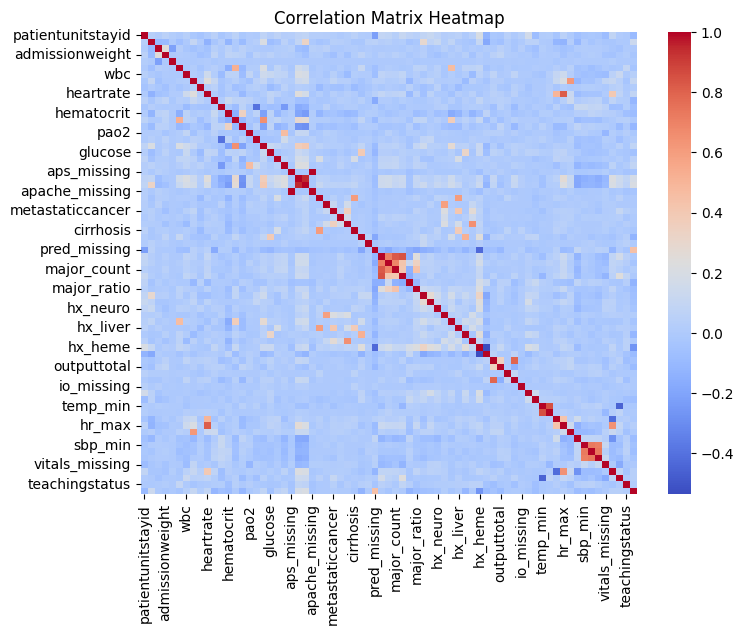

In [18]:
# Calculate correlation matrix

df_numerical=df.select_dtypes(include='number')
correlation_matrix = df_numerical.corr()

# Heatmap of the correlation matrix
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix Heatmap')
plt.show()

In [19]:
high_corr = (
    correlation_matrix.abs()
    .unstack()
    .sort_values(ascending=False))

high_corr = high_corr[high_corr < 1]  # remove self-correlation
high_corr = high_corr[high_corr > 0.80]

print("Features that are 80% correlated with each other:\n")
print(high_corr.head(20))

Features that are 80% correlated with each other:

apachescore           acutephysiologyscore    0.946201
acutephysiologyscore  apachescore             0.946201
temp_max              temp_min                0.854918
temp_min              temp_max                0.854918
total_diagnoses       other_count             0.847236
other_count           total_diagnoses         0.847236
total_diagnoses       major_count             0.825998
major_count           total_diagnoses         0.825998
hr_max                heartrate               0.816877
heartrate             hr_max                  0.816877
dtype: float64


In [20]:
target_corr = df.corr(numeric_only=True)["bad_outcome"].sort_values(ascending=False)
print("Feature correlations with the target feature:\n")
print(target_corr)

Feature correlations with the target feature:

bad_outcome             1.000000
pred_missing            0.444859
apachescore             0.202907
acutephysiologyscore    0.182867
age                     0.135446
                          ...   
hx_endocrine           -0.113875
albumin                -0.115143
diabetes               -0.128419
primary_ratio          -0.128423
hx_heme                -0.268781
Name: bad_outcome, Length: 71, dtype: float64


In [21]:
print("Specific feature correlations to look at with the target feature:\n")
print(target_corr[["apachescore", "acutephysiologyscore", "temp_min", "temp_max", "temp_range", "total_diagnoses", "primary_count", 
                  "major_count", "other_count", "primary_ratio", "major_ratio", "hr_max", "heartrate"]])

Specific feature correlations to look at with the target feature:

apachescore             0.202907
acutephysiologyscore    0.182867
temp_min               -0.018101
temp_max                0.001410
temp_range              0.037218
total_diagnoses         0.002889
primary_count          -0.031421
major_count             0.018478
other_count            -0.004829
primary_ratio          -0.128423
major_ratio            -0.075700
hr_max                  0.029949
heartrate               0.085045
Name: bad_outcome, dtype: float64


In [22]:
# Drop these features
df = df.drop(columns=[
    "total_diagnoses",
    "primary_count",
    "major_count",
    "other_count", "temp_max"])

In [23]:
# Compute VIF
X = df.drop(columns=["bad_outcome", "patientunitstayid"])

X = X.select_dtypes(include=["float64", "int64"])

vif_data = pd.DataFrame()
vif_data["feature"] = X.columns
vif_data["VIF"] = [
    variance_inflation_factor(X.values, i)
    for i in range(X.shape[1])]

vif_data = vif_data.sort_values(by="VIF", ascending=False)
print(vif_data.head(20))

/Users/marielle/jupyter_env/lib/python3.14/site-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


                 feature          VIF
23        apache_missing          inf
54                hr_max          inf
20           aps_missing          inf
53                hr_min          inf
61              hr_range          inf
10                    ph  1558.289152
7                 sodium   899.074930
52              temp_min   222.036394
22           apachescore   216.058947
21  acutephysiologyscore   146.520757
1        admissionheight   135.924927
57               sbp_min   108.102304
58               dbp_min    74.912067
15                  pco2    69.380202
13               albumin    67.419623
59               map_min    64.240750
11            hematocrit    51.496311
56              sao2_min    49.227323
8              heartrate    46.220156
60        vitals_missing    43.103271


The high VIF values **are not a major concern** in this case because the modeling approach is not relying on a single linear model that uses all features together. Instead, the plan is to use a stacked ensemble, where different groups of features are used in separate base models.

For example, the APACHE-related variables (such as apachescore and acutephysiologyscore) are intended to be used together in their own model, while the remaining clinical, demographic, laboratory, and vital sign features are used in a separate model. The final prediction is then generated by combining the outputs of these base models.

Because of this structure, multicollinearity between features across different groups is no longer a problem in the same way it would be in a single linear model. VIF assumes all predictors are used simultaneously in one equation, which is not the case here.

However, VIF is still useful for identifying true redundancy within feature groups. Features that are exact linear combinations of others (such as diagnosis count variables or overlapping min/max/range variables) should still be simplified or removed to reduce unnecessary duplication.

In summary, high VIF values are acceptable given the stacked modeling approach, and feature selection should focus mainly on removing exact duplicates and structurally redundant variables rather than aggressively eliminating correlated clinical features.

In [24]:
df.shape

(2520, 71)

**Data Viz**

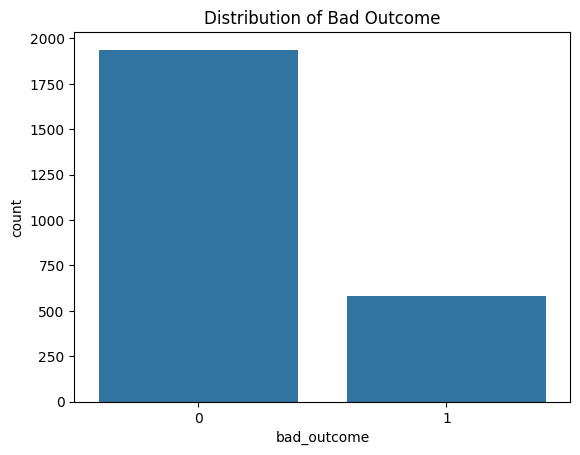

bad_outcome
0    1938
1     582
Name: count, dtype: int64
bad_outcome
0    0.769048
1    0.230952
Name: proportion, dtype: float64


In [25]:
sns.countplot(x='bad_outcome', data=df)
plt.title('Distribution of Bad Outcome')
plt.show()
print(df['bad_outcome'].value_counts())
print(df['bad_outcome'].value_counts(normalize=True))

/var/folders/64/98jnyqxj44scrcmg1y921n_40000gp/T/ipykernel_49204/1355065800.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include='object').columns


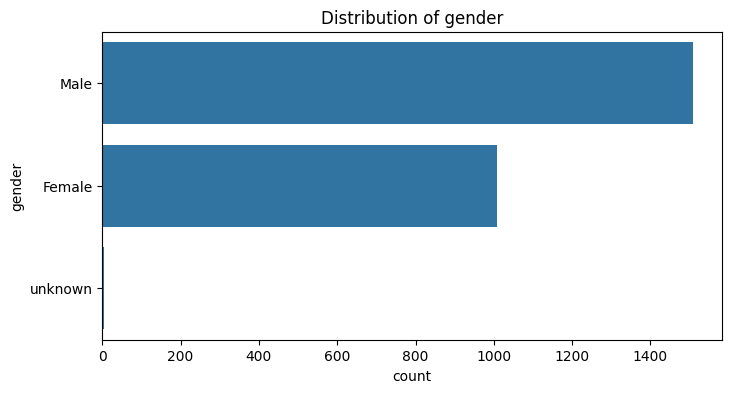

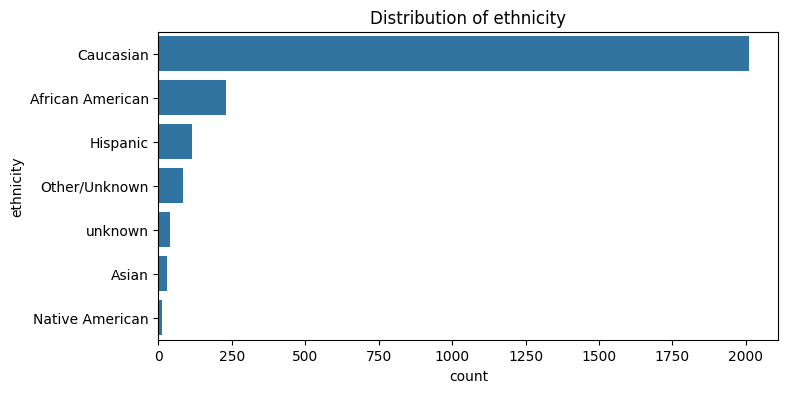

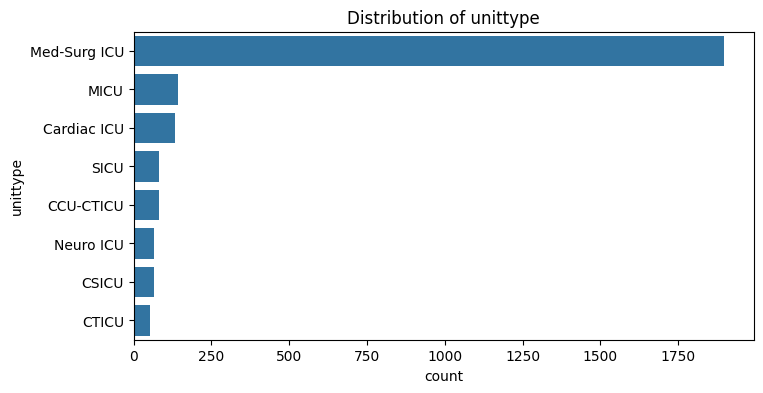

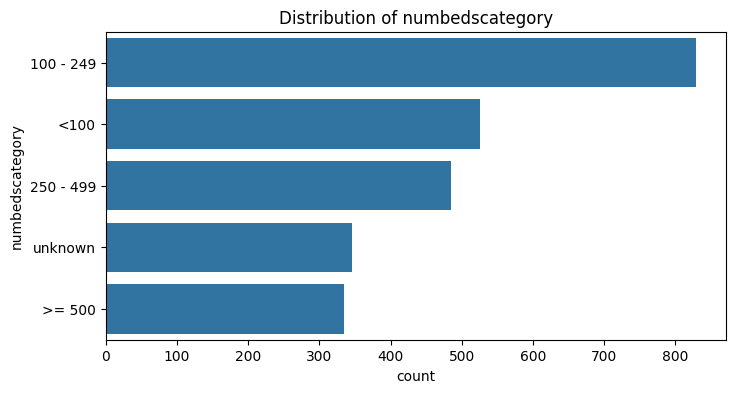

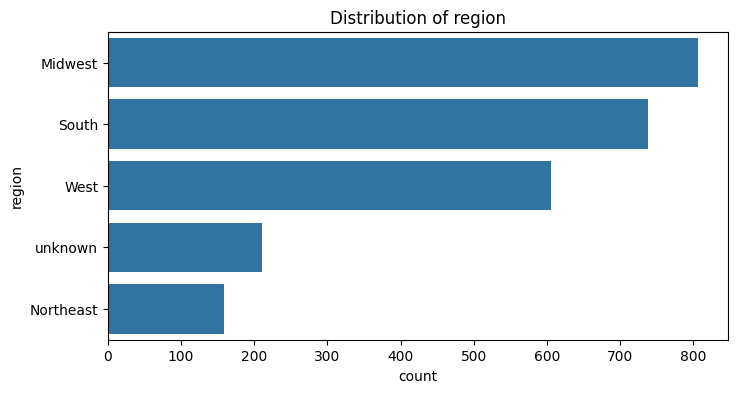

In [26]:
# Visualize categorical features
cat_cols = df.select_dtypes(include='object').columns

for col in cat_cols:
    plt.figure(figsize=(8,4))
    sns.countplot(y=col, data=df, order=df[col].value_counts().index)
    plt.title(f'Distribution of {col}')
    plt.show()

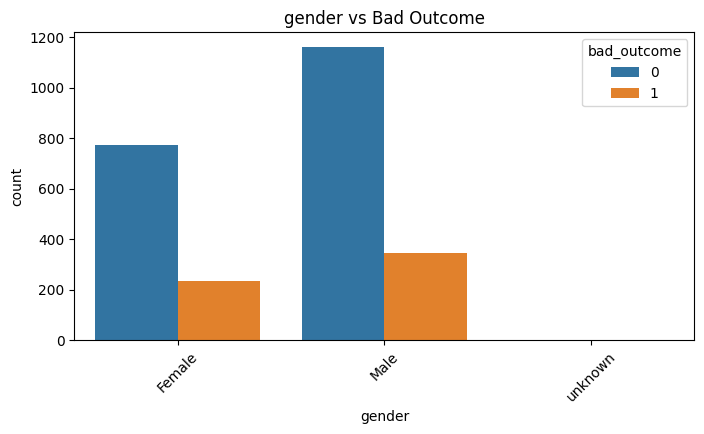

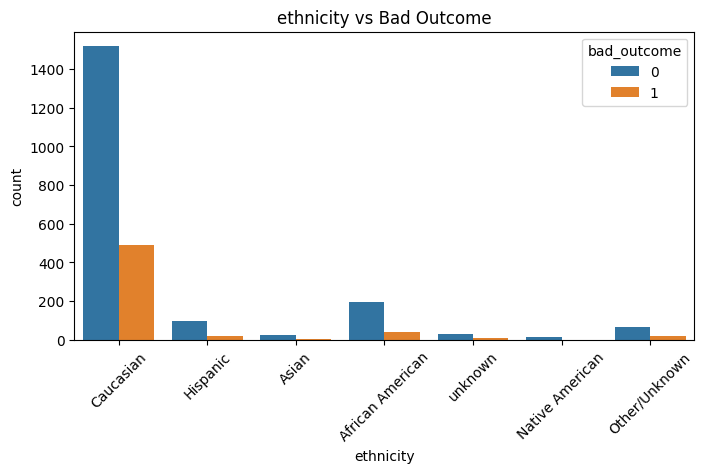

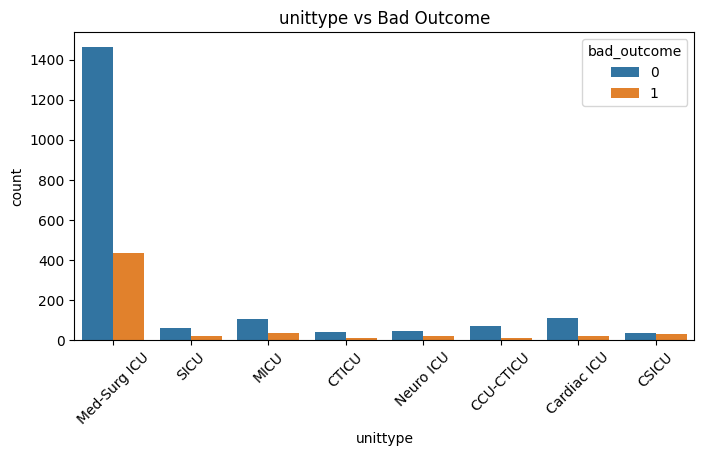

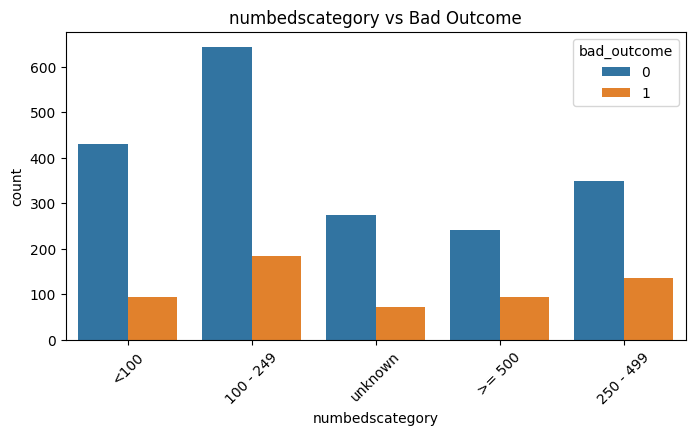

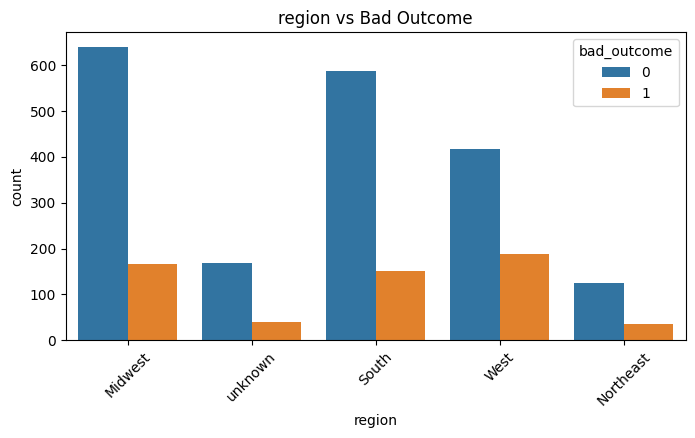

In [27]:
# Visualize categorical features against target feature
for col in cat_cols:
    plt.figure(figsize=(8,4))
    sns.countplot(x=col, hue='bad_outcome', data=df)
    plt.title(f'{col} vs Bad Outcome')
    plt.xticks(rotation=45)
    plt.show()

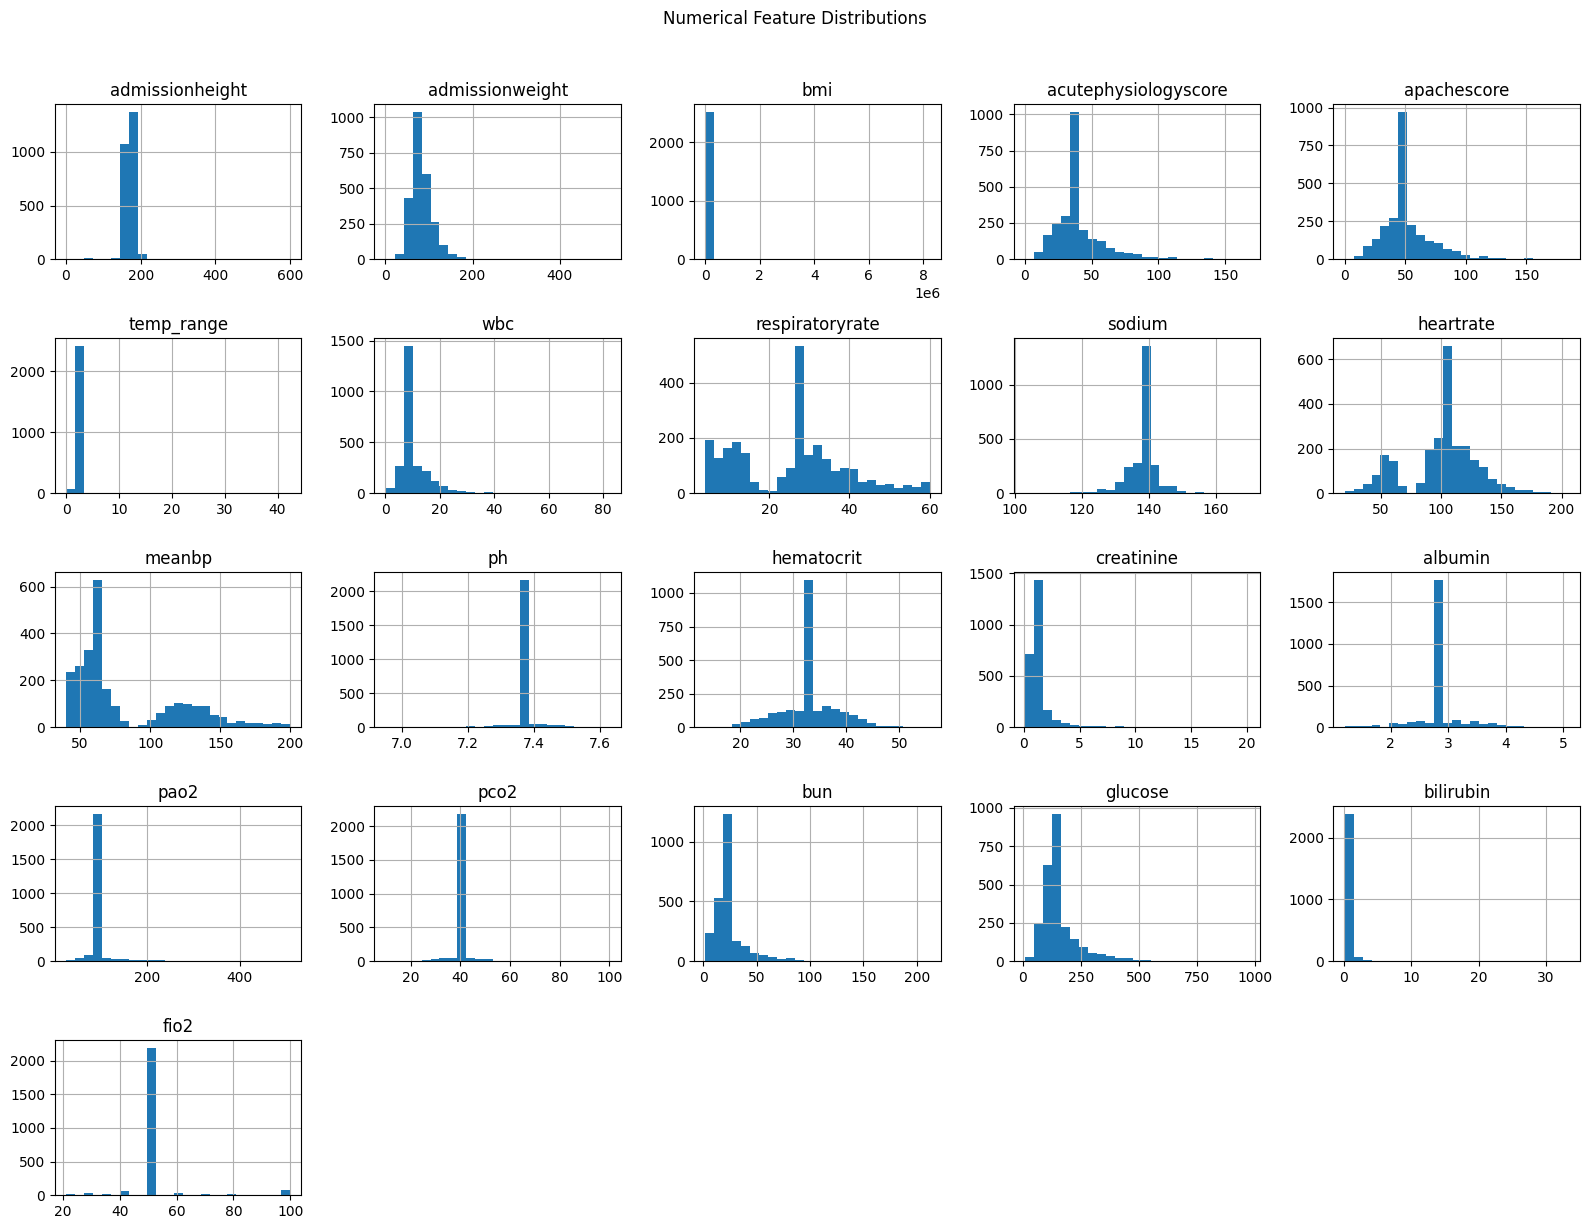

In [28]:
# Visualize select numerical features minus binary features

binary_cols = [
    "vitals_missing","io_missing","pred_missing","apache_missing","aps_missing",
    "bad_outcome","dialysis","hx_cardio","hx_respiratory","hx_neuro","hx_cancer",
    "hx_renal","hx_liver","hx_endocrine","hx_immuno","hx_heme","hx_none",
    "drug_allergy","non_drug_allergy","immunosuppression","midur","diabetes",
    "cirrhosis","leukemia","metastaticcancer","hepaticfailure","lymphoma",
    "teachingstatus"]

num_cols = [
    'admissionheight', 'admissionweight', 'bmi',
    'acutephysiologyscore', 'apachescore',
    'primary_count', 'major_count',
    'temp_range',
    'wbc', 'respiratoryrate', 'sodium', 'heartrate',
    'meanbp', 'ph', 'hematocrit', 'creatinine',
    'albumin', 'pao2', 'pco2', 'bun',
    'glucose', 'bilirubin', 'fio2']

# (optional safety: ensure they exist)
num_cols = [c for c in num_cols if c in df.columns]
df_plot = df.sample(2000, random_state=42) if len(df) > 5000 else df
df_plot[num_cols].hist(bins=25, figsize=(16, 12))
plt.suptitle("Numerical Feature Distributions", y=1.02)
plt.tight_layout()
plt.show()

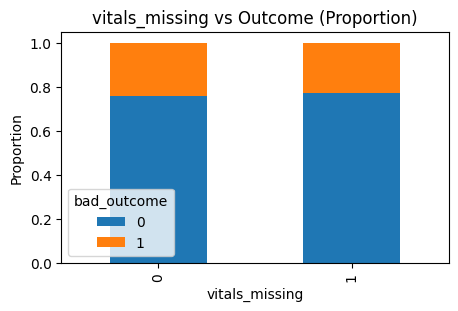

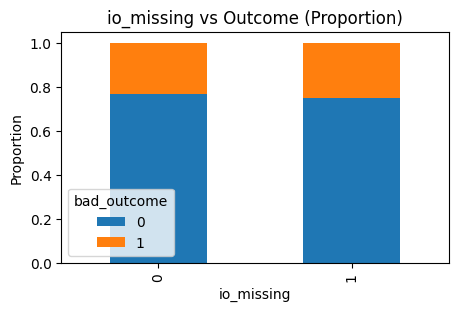

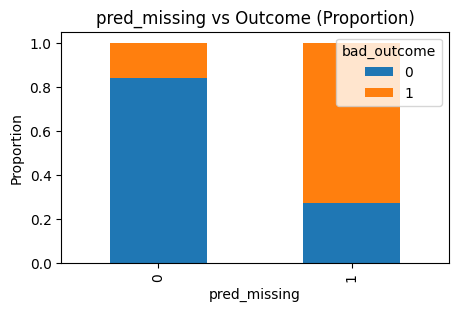

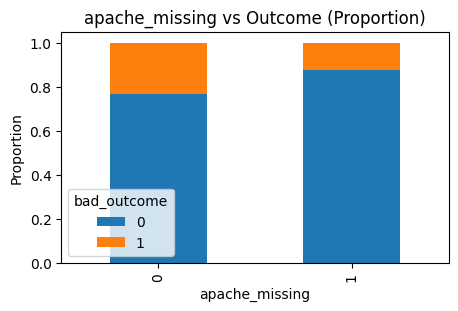

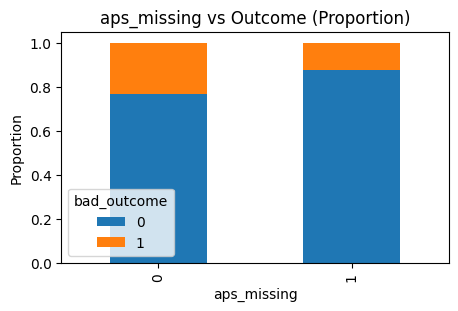

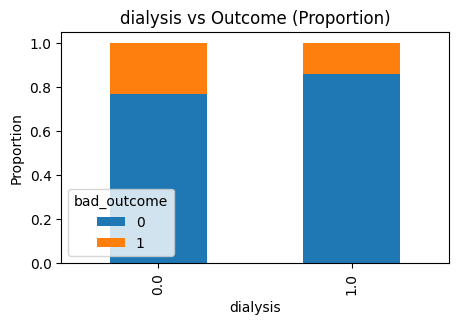

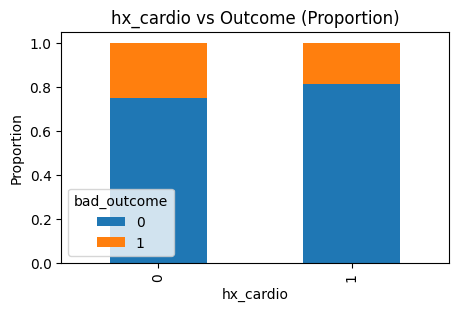

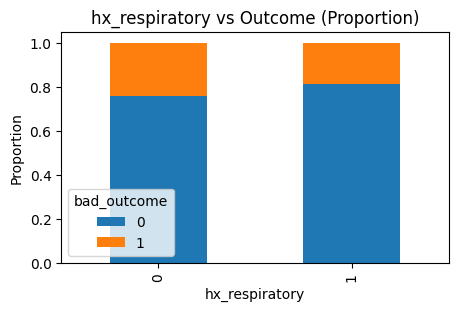

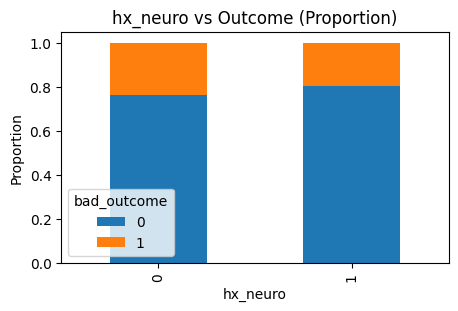

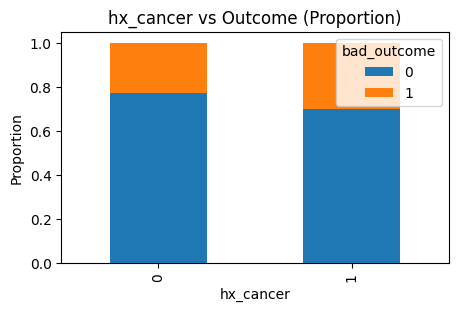

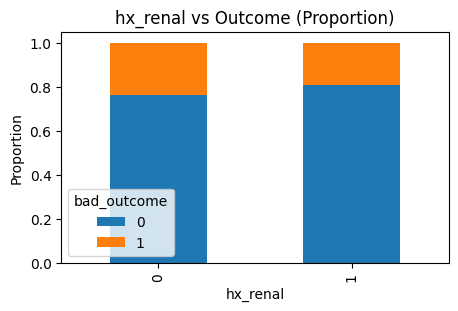

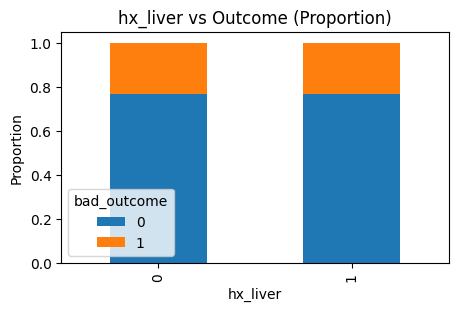

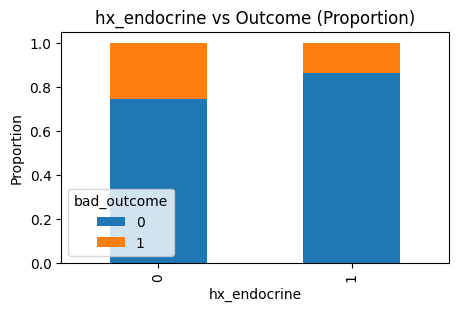

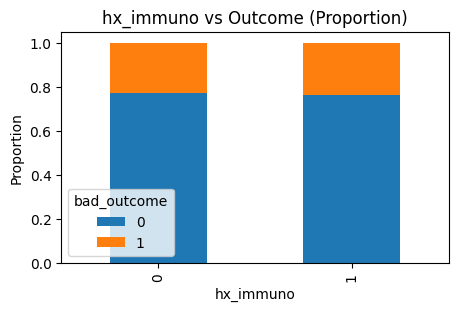

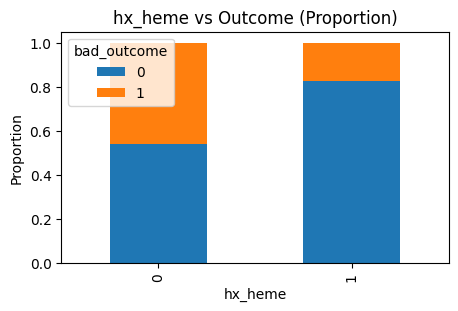

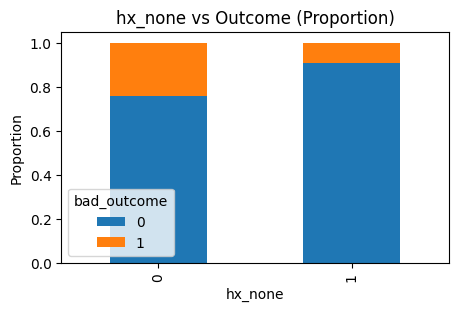

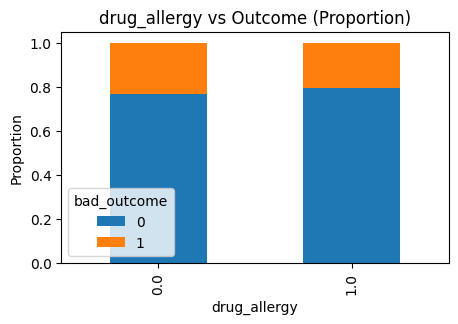

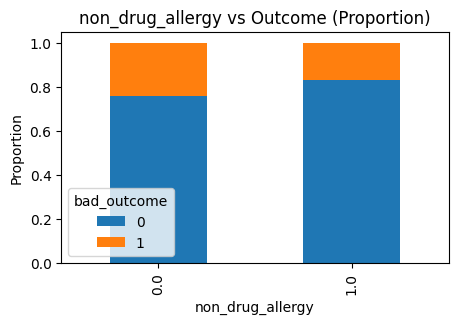

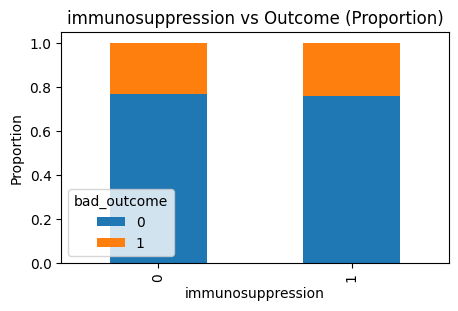

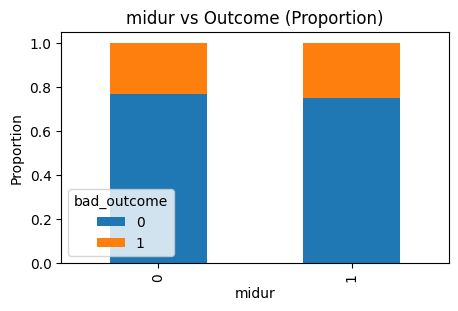

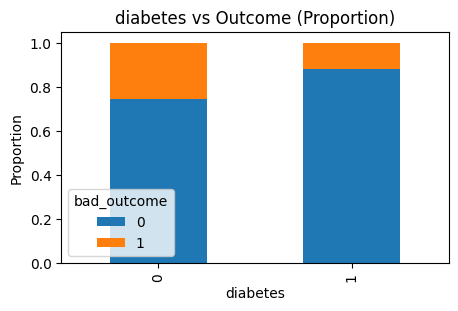

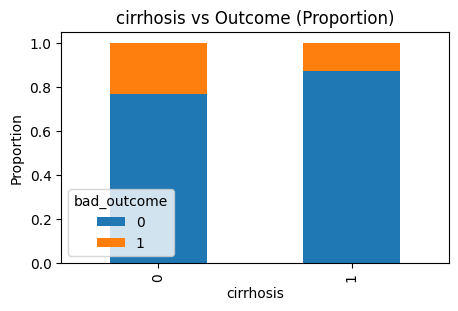

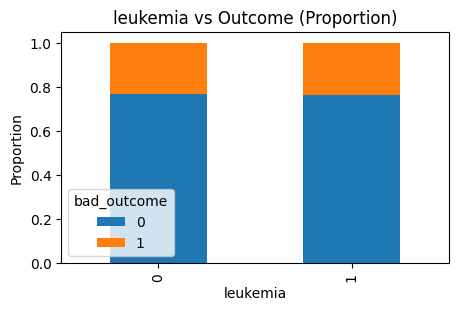

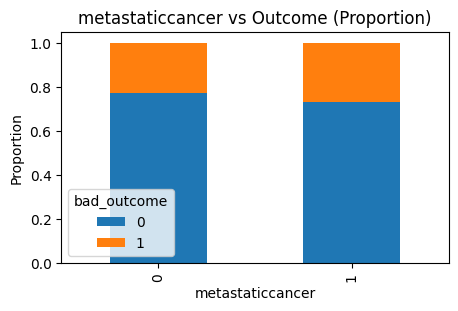

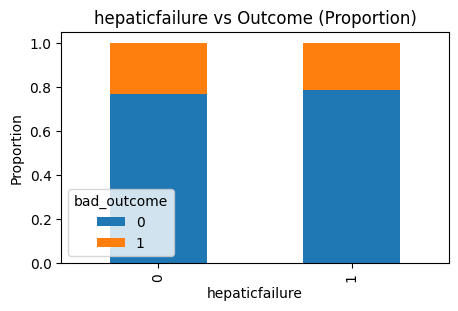

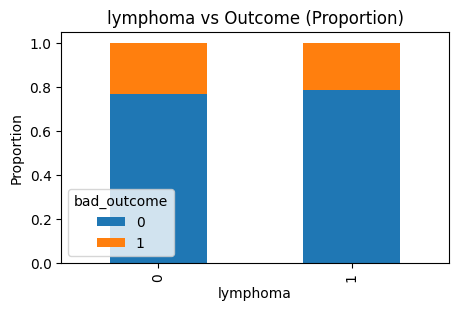

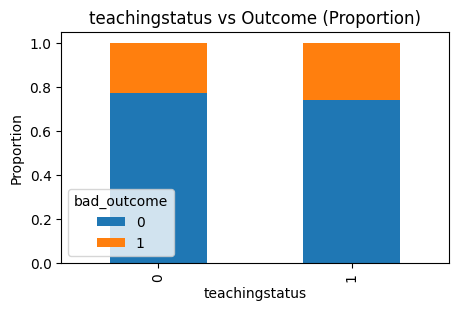

In [29]:
# Visualize binary features
binary_cols = [
    "vitals_missing","io_missing","pred_missing","apache_missing","aps_missing",
    "bad_outcome","dialysis","hx_cardio","hx_respiratory","hx_neuro","hx_cancer",
    "hx_renal","hx_liver","hx_endocrine","hx_immuno","hx_heme","hx_none",
    "drug_allergy","non_drug_allergy","immunosuppression","midur","diabetes",
    "cirrhosis","leukemia","metastaticcancer","hepaticfailure","lymphoma",
    "teachingstatus"]

binary_features = [col for col in binary_cols if col != "bad_outcome"]

for col in binary_features:
    pd.crosstab(df[col], df['bad_outcome'], normalize='index').plot(
        kind='bar', stacked=True, figsize=(5,3))
    plt.title(f'{col} vs Outcome (Proportion)')
    plt.ylabel('Proportion')
    plt.show()

**One-Hot or Label Encode Categorical Features**

**Categorical features**
- gender: Female, Male, unknown
- ethnicity: Caucasian, Hispanic, Asian, African American, unknown, Native American, Other/Uknown
- unittype: Med-Surg ICU, SICU, MICU, CTICU, Neuro ICU, CCU-CTICU, Cardiac ICU, CSICU
- numbedscategory: <100, 100 - 249, unknown, >= 500, 250 - 499
- region: Midwest, unknown, South, West, Northeast

In [30]:
df["ethnicity"] = df["ethnicity"].replace({
    "Other/Uknown": "Unknown",
    "Other/Unknown": "Unknown"}) # Combines these two variables together

# Standardize words
df["gender"] = df["gender"].replace("unknown", "Unknown")
df["region"] = df["region"].replace("unknown", "Unknown")
df["ethnicity"] = df["ethnicity"].fillna("Unknown")
df["gender"] = df["gender"].fillna("Unknown")
df["region"] = df["region"].fillna("Unknown")

In [31]:
# Ordinal encoding for numbedscategory
df["numbed_missing"] = df["numbedscategory"].eq("unknown").astype(int)

mapping = {
    "<100": 1,
    "100 - 249": 2,
    "250 - 499": 3,
    ">= 500": 4}

df["numbedscategory"] = df["numbedscategory"].map(mapping)

df["numbedscategory"] = df["numbedscategory"].fillna(df["numbedscategory"].median())

In [32]:
# One-hot encode for the rest of the categoricals
cat_cols = ["gender", "ethnicity", "unittype", "region"]
df = pd.get_dummies(df, columns=cat_cols, drop_first=True)

In [33]:
# Changes True to 1 and False to 0
bool_cols = df.select_dtypes(include='bool').columns
df[bool_cols] = df[bool_cols].astype(int)

In [34]:
# Move bad outcome to the end
cols = [col for col in df.columns if col != 'bad_outcome'] + ['bad_outcome']
df = df[cols]

In [35]:
df.head()

,patientunitstayid,age,admissionheight,admissionweight,bmi,dialysis,wbc,respiratoryrate,sodium,heartrate,meanbp,ph,hematocrit,creatinine,albumin,pao2,pco2,bun,glucose,bilirubin,fio2,aps_missing,acutephysiologyscore,apachescore,apache_missing,hepaticfailure,lymphoma,metastaticcancer,leukemia,immunosuppression,cirrhosis,diabetes,midur,pred_missing,primary_ratio,major_ratio,hx_cardio,hx_respiratory,hx_neuro,hx_cancer,hx_renal,hx_liver,hx_endocrine,hx_immuno,hx_heme,hx_none,intaketotal,outputtotal,dialysistotal,nettotal,io_missing,drug_allergy,non_drug_allergy,temp_min,hr_min,hr_max,resp_max,sao2_min,sbp_min,dbp_min,map_min,vitals_missing,hr_range,temp_range,numbedscategory,teachingstatus,numbed_missing,gender_Male,gender_Unknown,ethnicity_Asian,ethnicity_Caucasian,ethnicity_Hispanic,ethnicity_Native American,ethnicity_Unknown,ethnicity_unknown,unittype_CSICU,unittype_CTICU,unittype_Cardiac ICU,unittype_MICU,unittype_Med-Surg ICU,unittype_Neuro ICU,unittype_SICU,region_Northeast,region_South,region_Unknown,region_West,bad_outcome
0,141764,87.0,157.5,79.3,27.298480,0.0,9.9,27.0,138.0,104.0,65.0,7.38,33.5,1.00,2.9,102.0,40.3,20.0,128.0,0.6,50.0,0,36.0,48.0,0,0,0,0,0,0,0,0,0,1,0.000000,0.000000,0,0,0,0,0,0,0,0,0,0,200.0,500.0,0.0,100.0,0,0.0,0.0,36.0,90.0,138.0,29.0,90.0,84.0,44.0,58.0,1,48.0,1.8,1.0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1
1,141765,87.0,157.5,46.5,18.745276,0.0,10.2,39.0,139.0,88.0,108.0,7.38,37.8,1.04,2.9,102.0,40.3,28.0,61.0,0.6,50.0,0,23.0,47.0,0,0,0,0,0,0,0,0,0,0,0.000000,0.000000,0,0,0,0,0,0,0,0,0,1,1029.0,600.0,0.0,1029.0,0,0.0,0.0,36.0,72.0,116.0,39.0,95.0,84.0,44.0,58.0,1,44.0,1.8,1.0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0
2,143870,76.0,167.0,77.5,27.788734,0.0,11.7,60.0,133.0,40.0,47.0,7.38,34.1,1.14,2.9,102.0,40.3,14.0,140.0,0.6,50.0,0,43.0,60.0,0,0,0,0,0,0,0,0,0,0,0.333333,0.333333,0,0,0,0,0,0,0,0,0,1,1556.0,300.0,0.0,1556.0,0,0.0,0.0,36.0,40.0,55.0,86.0,80.0,53.0,36.0,47.0,1,15.0,1.8,1.0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0
3,144815,34.0,172.7,60.3,20.217741,0.0,7.9,6.0,141.0,131.0,61.0,7.38,36.6,0.63,3.6,102.0,40.3,6.0,82.0,0.5,50.0,0,25.0,25.0,0,0,0,0,0,0,0,0,0,0,0.000000,0.000000,0,0,0,0,0,0,0,0,0,1,1330.0,900.0,0.0,1329.0,0,0.0,0.0,36.0,68.0,118.0,42.0,96.0,84.0,44.0,58.0,1,50.0,1.8,1.0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0
4,145427,61.0,177.8,91.7,29.007201,0.0,21.1,41.0,141.0,49.0,72.0,7.38,40.4,1.05,2.9,102.0,40.3,14.0,118.0,0.6,50.0,0,26.0,37.0,0,0,0,0,0,0,0,0,0,0,0.375000,0.375000,0,0,0,0,0,0,0,0,0,1,1000.0,1000.0,0.0,1000.0,0,0.0,0.0,36.0,49.0,85.0,41.0,89.0,84.0,44.0,58.0,1,36.0,1.8,1.0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0


In [36]:
df.shape

(2520, 87)

In [37]:
df.to_csv("final_merged_cleaned_preprocessed.csv", index=False)